# Práctica: Modelos de regresión – Ejercicios de extracción

**Materia:** Tópicos de Big Data  
**Tema:** Regresión lineal, regresión polinomial y Random Forest

## Objetivo

Utilizando como base el notebook original, repetir el proceso de los tres modelos:

1. **Regresión Lineal (RL)**
2. **Regresión Polinomial (RP)**
3. **Random Forest (RF)**

para resolver los siguientes ejercicios:

- **Ejercicio 1:** Extraer el país de **China** y realizar las proyecciones.
- **Ejercicio 2:** Extraer **nacimientos y defunciones de México a partir del año 2000** y realizar las proyecciones.

Se conserva la misma lógica del notebook original: los modelos se entrenan con datos históricos y se generan predicciones para los años posteriores a 2023.

# PARTE 1. Importar las bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestRegressor

# PARTE 2. Cargar el dataset

Usamos el mismo dataset del notebook original de Our World in Data.

In [2]:
url = "https://ourworldindata.org/grapher/births-and-deaths-projected-to-2100.csv?v=1&csvType=full&useColumnShortNames=true"

try:
    df = pd.read_csv(
        url,
        storage_options={
            "User-Agent": "Our World In Data data fetch/1.0"
        }
    )
except Exception as error:
    print("No fue posible descargar el archivo desde internet:", error)
    print("Se utilizará el archivo local 'births-and-deaths-projected-to-2100.csv'")
    df = pd.read_csv("births-and-deaths-projected-to-2100.csv")

print("Dimensiones:", df.shape)
df.head()

Dimensiones: (39562, 7)


,entity,code,year,deaths__sex_all__age_all__variant_estimates,deaths__sex_all__age_all__variant_medium__projected,births__sex_all__age_all__variant_estimates,births__sex_all__age_all__variant_medium__projected
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN


In [3]:
df = df.rename(columns={
    "entity": "Entity",
    "code": "Code",
    "year": "Year",
    "births__sex_all__age_all__variant_estimates": "births_estimates",
    "births__sex_all__age_all__variant_medium__projected": "births_projected",
    "deaths__sex_all__age_all__variant_estimates": "deaths_estimates",
    "deaths__sex_all__age_all__variant_medium__projected": "deaths_projected",
})

df["births"] = df["births_estimates"].fillna(df["births_projected"])
df["deaths"] = df["deaths_estimates"].fillna(df["deaths_projected"])

df.head()

,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
0,Afghanistan,AFG,1950,290972.0,NaN,383985.0,NaN,383985.0,290972.0
1,Afghanistan,AFG,1951,288752.0,NaN,391002.0,NaN,391002.0,288752.0
2,Afghanistan,AFG,1952,288059.0,NaN,397663.0,NaN,397663.0,288059.0
3,Afghanistan,AFG,1953,287712.0,NaN,404666.0,NaN,404666.0,287712.0
4,Afghanistan,AFG,1954,289189.0,NaN,410428.0,NaN,410428.0,289189.0


# PARTE 3. Separar datos históricos y proyectados

Al igual que en el notebook original, utilizaremos **2023 como último año histórico**.

In [4]:
ultimo_historico = df.loc[df["births_estimates"].notna(), "Year"].max()
primera_proyeccion = df.loc[df["births_projected"].notna(), "Year"].min()

print("Último año con dato histórico:", ultimo_historico)
print("Primer año con proyección:", primera_proyeccion)

df_historico = df[df["Year"] <= 2023].copy()
df_proyectado = df[df["Year"] > 2023].copy()

print("Histórico:", df_historico["Year"].min(), "a", df_historico["Year"].max())
print("Proyectado:", df_proyectado["Year"].min(), "a", df_proyectado["Year"].max())

Último año con dato histórico: 2023
Primer año con proyección: 2024
Histórico: 1950 a 2023
Proyectado: 2024 a 2100


# EJERCICIO 1. Extraer China

Primero filtramos únicamente la entidad **China**.

In [5]:
pais_china = "China"

df_china = df[df["Entity"] == pais_china].copy()

print("Rango de años:", df_china["Year"].min(), "-", df_china["Year"].max())
print("Número de filas:", df_china.shape[0])

df_china.head()

Rango de años: 1950 - 2100
Número de filas: 151


,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
7097,China,CHN,1950,12564023.0,NaN,22293376.0,NaN,22293376.0,12564023.0
7098,China,CHN,1951,12411701.0,NaN,22144814.0,NaN,22144814.0,12411701.0
7099,China,CHN,1952,12459848.0,NaN,25496318.0,NaN,25496318.0,12459848.0
7100,China,CHN,1953,12309525.0,NaN,24139416.0,NaN,24139416.0,12309525.0
7101,China,CHN,1954,12145578.0,NaN,25438544.0,NaN,25438544.0,12145578.0


In [6]:
df_china_historico = df_china[df_china["Year"] <= 2023].copy()
df_china_proyectado = df_china[df_china["Year"] > 2023].copy()

print("China histórico:", df_china_historico["Year"].min(), "a", df_china_historico["Year"].max())
print("China proyectado:", df_china_proyectado["Year"].min(), "a", df_china_proyectado["Year"].max())

print("\nValores faltantes:")
print(df_china_historico[["Year", "births", "deaths"]].isna().sum())

China histórico: 1950 a 2023
China proyectado: 2024 a 2100

Valores faltantes:
Year      0
births    0
deaths    0
dtype: int64


## 1.1 China – datos históricos

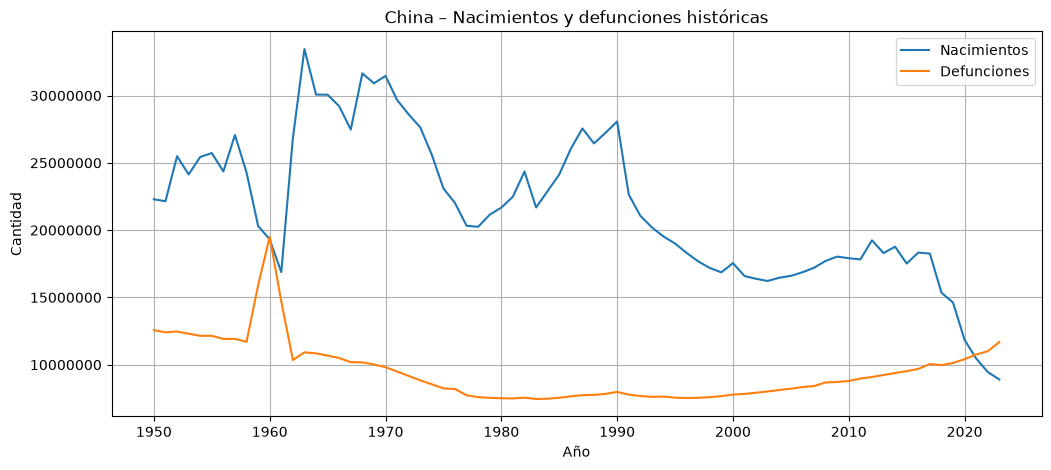

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(df_china_historico["Year"], df_china_historico["births"],
         label="Nacimientos")
plt.plot(df_china_historico["Year"], df_china_historico["deaths"],
         label="Defunciones")

plt.title("China – Nacimientos y defunciones históricas")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 1.2 China – preparar variables

La variable predictora es el **año**. La variable objetivo será, primero, **nacimientos**.

In [8]:
X_china = df_china_historico[["Year"]]
y_china_births = df_china_historico["births"]

anios_futuros = np.arange(2024, 2101).reshape(-1, 1)
X_china_futuro = pd.DataFrame(anios_futuros, columns=["Year"])

print("X:", X_china.shape)
print("y:", y_china_births.shape)

X: (74, 1)
y: (74,)


## 1.3 China – Modelo 1: Regresión Lineal

In [9]:
modelo_lineal_china = LinearRegression()
modelo_lineal_china.fit(X_china, y_china_births)

pred_lineal_china_hist = modelo_lineal_china.predict(X_china)
pred_lineal_china_fut = modelo_lineal_china.predict(X_china_futuro)

print("Pendiente:", modelo_lineal_china.coef_[0])
print("Intercepto:", modelo_lineal_china.intercept_)

Pendiente: -187208.31004813028
Intercepto: 393489519.9376378


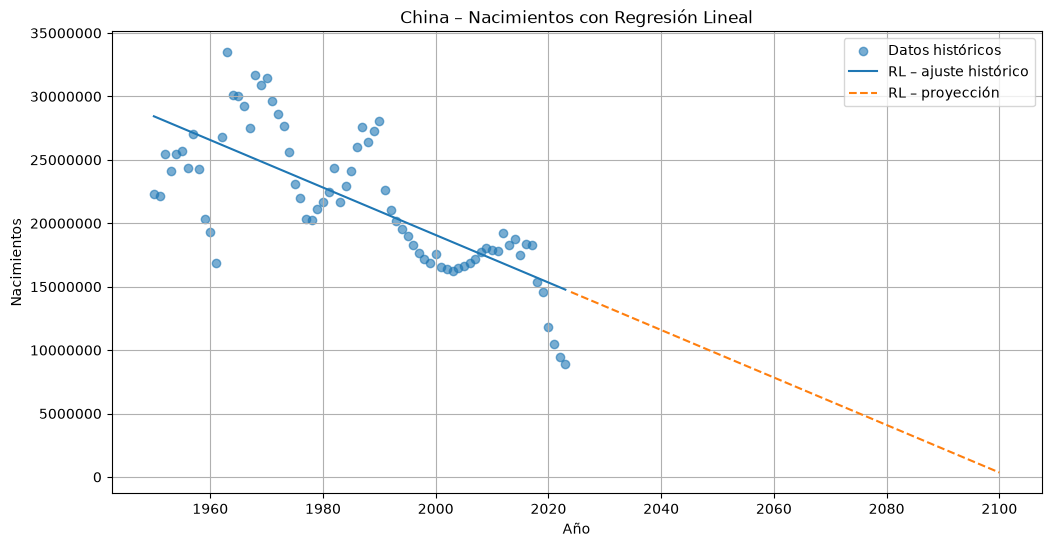

In [10]:
plt.figure(figsize=(12, 6))

plt.scatter(df_china_historico["Year"], df_china_historico["births"],
            label="Datos históricos", alpha=0.6)

plt.plot(df_china_historico["Year"], pred_lineal_china_hist,
         label="RL – ajuste histórico")

plt.plot(X_china_futuro["Year"], pred_lineal_china_fut,
         linestyle="--", label="RL – proyección")

plt.title("China – Nacimientos con Regresión Lineal")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 1.4 China – Modelo 2: Regresión Polinomial

In [11]:
poly_china = PolynomialFeatures(degree=2, include_bias=False)

X_china_poly = poly_china.fit_transform(X_china)
X_china_futuro_poly = poly_china.transform(X_china_futuro)

modelo_polinomial_china = LinearRegression()
modelo_polinomial_china.fit(X_china_poly, y_china_births)

pred_poly_china_hist = modelo_polinomial_china.predict(X_china_poly)
pred_poly_china_fut = modelo_polinomial_china.predict(X_china_futuro_poly)

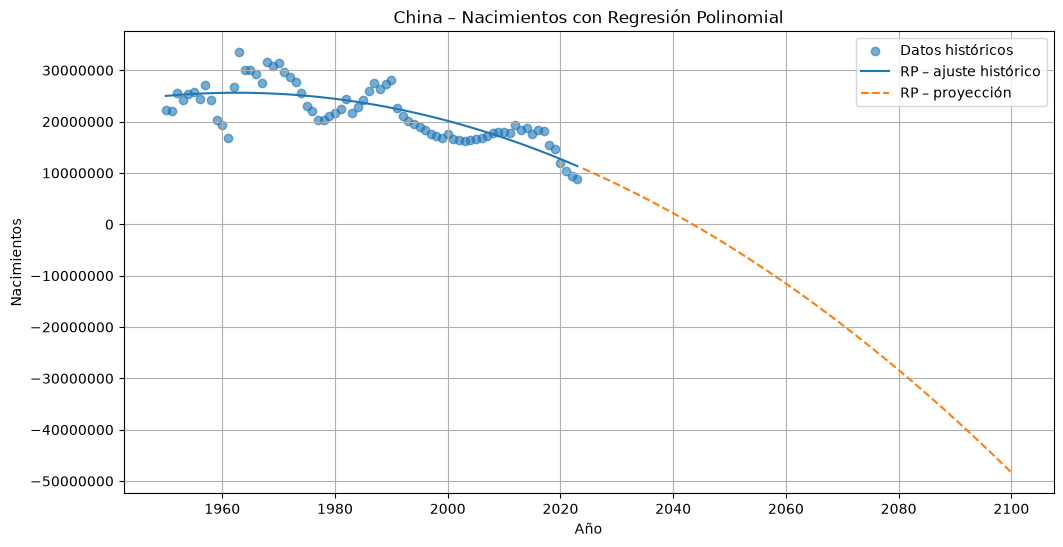

In [12]:
plt.figure(figsize=(12, 6))

plt.scatter(df_china_historico["Year"], df_china_historico["births"],
            label="Datos históricos", alpha=0.6)

plt.plot(df_china_historico["Year"], pred_poly_china_hist,
         label="RP – ajuste histórico")

plt.plot(X_china_futuro["Year"], pred_poly_china_fut,
         linestyle="--", label="RP – proyección")

plt.title("China – Nacimientos con Regresión Polinomial")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 1.5 China – Modelo 3: Random Forest

In [13]:
modelo_rf_china = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

modelo_rf_china.fit(X_china, y_china_births)

pred_rf_china_hist = modelo_rf_china.predict(X_china)
pred_rf_china_fut = modelo_rf_china.predict(X_china_futuro)

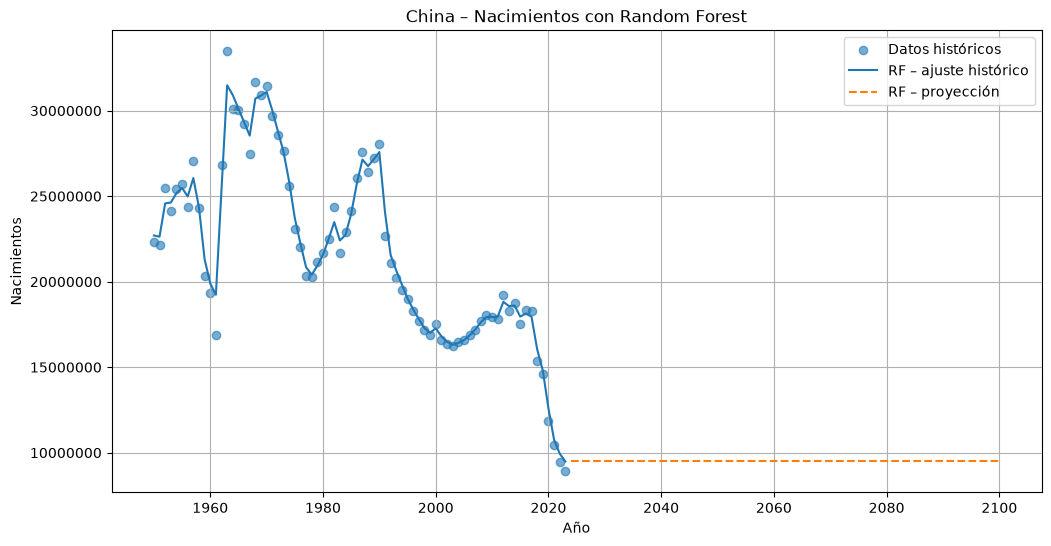

In [14]:
plt.figure(figsize=(12, 6))

plt.scatter(df_china_historico["Year"], df_china_historico["births"],
            label="Datos históricos", alpha=0.6)

plt.plot(df_china_historico["Year"], pred_rf_china_hist,
         label="RF – ajuste histórico")

plt.plot(X_china_futuro["Year"], pred_rf_china_fut,
         linestyle="--", label="RF – proyección")

plt.title("China – Nacimientos con Random Forest")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

## 1.6 China – Comparación de los tres modelos

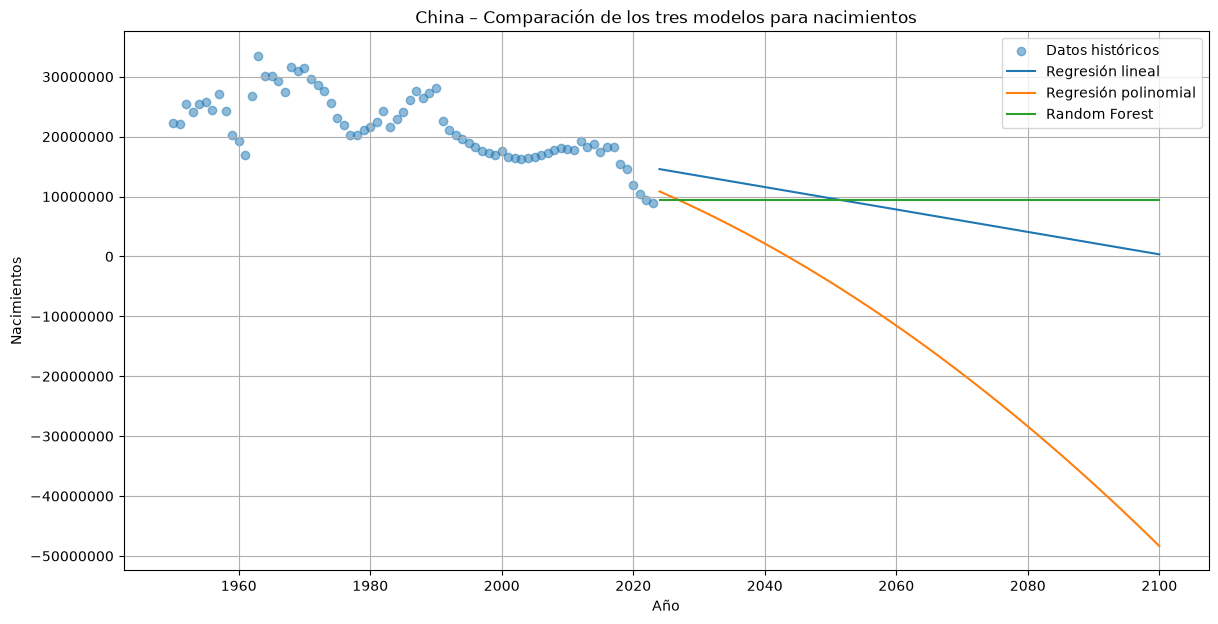

In [15]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_china_historico["Year"],
    df_china_historico["births"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(X_china_futuro["Year"], pred_lineal_china_fut,
         label="Regresión lineal")

plt.plot(X_china_futuro["Year"], pred_poly_china_fut,
         label="Regresión polinomial")

plt.plot(X_china_futuro["Year"], pred_rf_china_fut,
         label="Random Forest")

plt.title("China – Comparación de los tres modelos para nacimientos")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# EJERCICIO 2. México: nacimientos y defunciones desde 2000

Ahora extraemos México y conservamos únicamente los registros **a partir del año 2000**.

In [16]:
pais_mexico = "Mexico"

df_mexico_2000 = df[
    (df["Entity"] == pais_mexico) &
    (df["Year"] >= 2000)
].copy()

print("Rango de años:", df_mexico_2000["Year"].min(), "-", df_mexico_2000["Year"].max())
print("Número de filas:", df_mexico_2000.shape[0])

df_mexico_2000.head()

Rango de años: 2000 - 2100
Número de filas: 101


,Entity,Code,Year,deaths_estimates,deaths_projected,births_estimates,births_projected,births,deaths
22851,Mexico,MEX,2000,540567.0,NaN,2385977.0,NaN,2385977.0,540567.0
22852,Mexico,MEX,2001,543803.0,NaN,2380261.0,NaN,2380261.0,543803.0
22853,Mexico,MEX,2002,553391.0,NaN,2374140.0,NaN,2374140.0,553391.0
22854,Mexico,MEX,2003,563140.0,NaN,2351177.0,NaN,2351177.0,563140.0
22855,Mexico,MEX,2004,575925.0,NaN,2335226.0,NaN,2335226.0,575925.0


In [17]:
df_mexico_2000_historico = df_mexico_2000[
    df_mexico_2000["Year"] <= 2023
].copy()

df_mexico_2000_proyectado = df_mexico_2000[
    df_mexico_2000["Year"] > 2023
].copy()

print("Histórico:", df_mexico_2000_historico["Year"].min(), "a",
      df_mexico_2000_historico["Year"].max())
print("Proyectado:", df_mexico_2000_proyectado["Year"].min(), "a",
      df_mexico_2000_proyectado["Year"].max())

print("\nValores faltantes:")
print(df_mexico_2000_historico[["Year", "births", "deaths"]].isna().sum())

Histórico: 2000 a 2023
Proyectado: 2024 a 2100

Valores faltantes:
Year      0
births    0
deaths    0
dtype: int64


## 2.1 México desde 2000 – visualizar nacimientos y defunciones

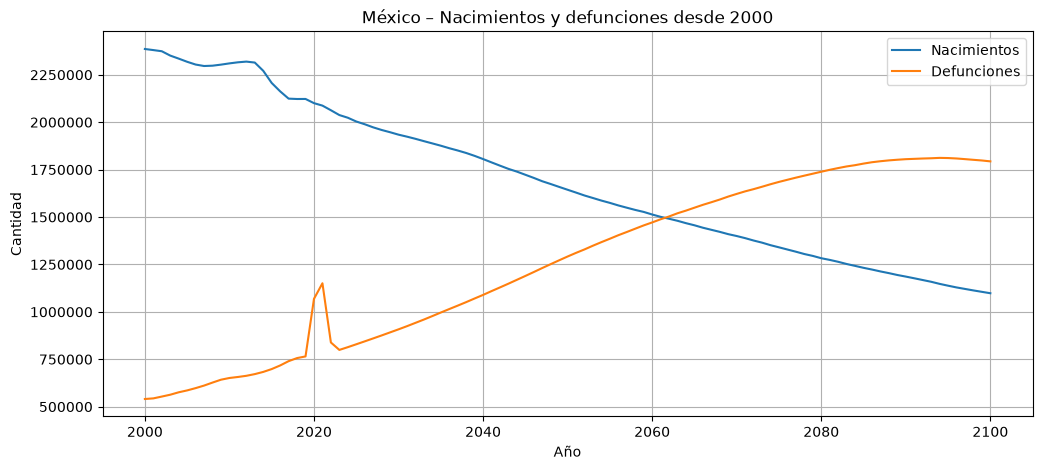

In [18]:
plt.figure(figsize=(12, 5))

plt.plot(df_mexico_2000["Year"], df_mexico_2000["births"],
         label="Nacimientos")
plt.plot(df_mexico_2000["Year"], df_mexico_2000["deaths"],
         label="Defunciones")

plt.title("México – Nacimientos y defunciones desde 2000")
plt.xlabel("Año")
plt.ylabel("Cantidad")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# 2.2 México – Nacimientos con los tres modelos

In [19]:
X_mexico = df_mexico_2000_historico[["Year"]]
y_mexico_births = df_mexico_2000_historico["births"]

X_mexico_futuro = pd.DataFrame(
    np.arange(2024, 2101).reshape(-1, 1),
    columns=["Year"]
)

# RL
modelo_lineal_mexico_births = LinearRegression()
modelo_lineal_mexico_births.fit(X_mexico, y_mexico_births)

pred_lineal_mexico_births_hist = modelo_lineal_mexico_births.predict(X_mexico)
pred_lineal_mexico_births_fut = modelo_lineal_mexico_births.predict(X_mexico_futuro)

# RP
poly_mexico_births = PolynomialFeatures(degree=2, include_bias=False)
X_mexico_poly_births = poly_mexico_births.fit_transform(X_mexico)
X_mexico_futuro_poly_births = poly_mexico_births.transform(X_mexico_futuro)

modelo_polinomial_mexico_births = LinearRegression()
modelo_polinomial_mexico_births.fit(X_mexico_poly_births, y_mexico_births)

pred_poly_mexico_births_hist = modelo_polinomial_mexico_births.predict(X_mexico_poly_births)
pred_poly_mexico_births_fut = modelo_polinomial_mexico_births.predict(X_mexico_futuro_poly_births)

# RF
modelo_rf_mexico_births = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
modelo_rf_mexico_births.fit(X_mexico, y_mexico_births)

pred_rf_mexico_births_hist = modelo_rf_mexico_births.predict(X_mexico)
pred_rf_mexico_births_fut = modelo_rf_mexico_births.predict(X_mexico_futuro)

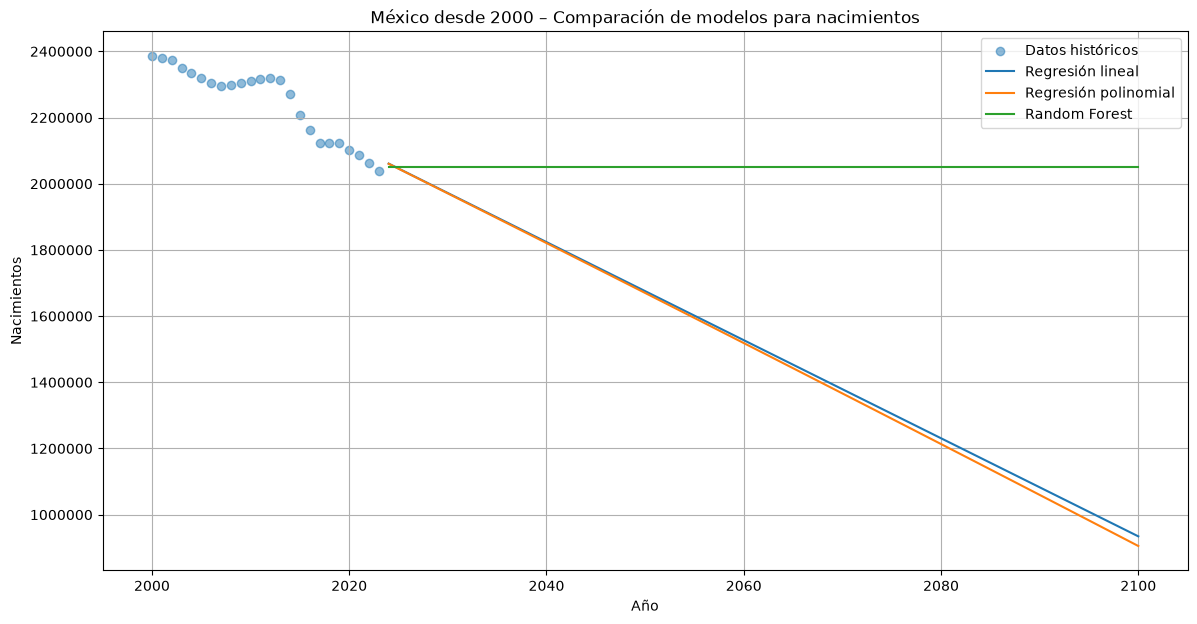

In [20]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_mexico_2000_historico["Year"],
    df_mexico_2000_historico["births"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(X_mexico_futuro["Year"], pred_lineal_mexico_births_fut,
         label="Regresión lineal")

plt.plot(X_mexico_futuro["Year"], pred_poly_mexico_births_fut,
         label="Regresión polinomial")

plt.plot(X_mexico_futuro["Year"], pred_rf_mexico_births_fut,
         label="Random Forest")

plt.title("México desde 2000 – Comparación de modelos para nacimientos")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# 2.3 México – Defunciones con los tres modelos

In [21]:
y_mexico_deaths = df_mexico_2000_historico["deaths"]

# RL
modelo_lineal_mexico_deaths = LinearRegression()
modelo_lineal_mexico_deaths.fit(X_mexico, y_mexico_deaths)

pred_lineal_mexico_deaths_hist = modelo_lineal_mexico_deaths.predict(X_mexico)
pred_lineal_mexico_deaths_fut = modelo_lineal_mexico_deaths.predict(X_mexico_futuro)

# RP
poly_mexico_deaths = PolynomialFeatures(degree=2, include_bias=False)
X_mexico_poly_deaths = poly_mexico_deaths.fit_transform(X_mexico)
X_mexico_futuro_poly_deaths = poly_mexico_deaths.transform(X_mexico_futuro)

modelo_polinomial_mexico_deaths = LinearRegression()
modelo_polinomial_mexico_deaths.fit(X_mexico_poly_deaths, y_mexico_deaths)

pred_poly_mexico_deaths_hist = modelo_polinomial_mexico_deaths.predict(X_mexico_poly_deaths)
pred_poly_mexico_deaths_fut = modelo_polinomial_mexico_deaths.predict(X_mexico_futuro_poly_deaths)

# RF
modelo_rf_mexico_deaths = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
modelo_rf_mexico_deaths.fit(X_mexico, y_mexico_deaths)

pred_rf_mexico_deaths_hist = modelo_rf_mexico_deaths.predict(X_mexico)
pred_rf_mexico_deaths_fut = modelo_rf_mexico_deaths.predict(X_mexico_futuro)

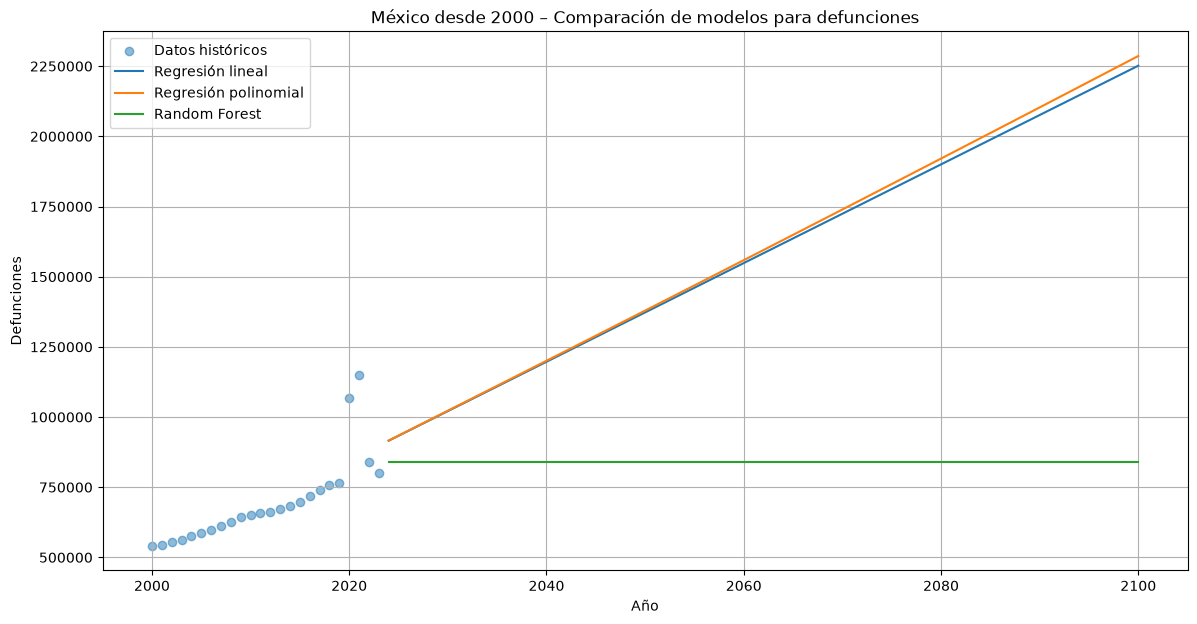

In [22]:
plt.figure(figsize=(14, 7))

plt.scatter(
    df_mexico_2000_historico["Year"],
    df_mexico_2000_historico["deaths"],
    label="Datos históricos",
    alpha=0.5
)

plt.plot(X_mexico_futuro["Year"], pred_lineal_mexico_deaths_fut,
         label="Regresión lineal")

plt.plot(X_mexico_futuro["Year"], pred_poly_mexico_deaths_fut,
         label="Regresión polinomial")

plt.plot(X_mexico_futuro["Year"], pred_rf_mexico_deaths_fut,
         label="Random Forest")

plt.title("México desde 2000 – Comparación de modelos para defunciones")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# 2.4 México – comparación con las proyecciones de OWID

Se muestran los tres modelos junto con la proyección disponible en el dataset para observar visualmente sus diferencias.

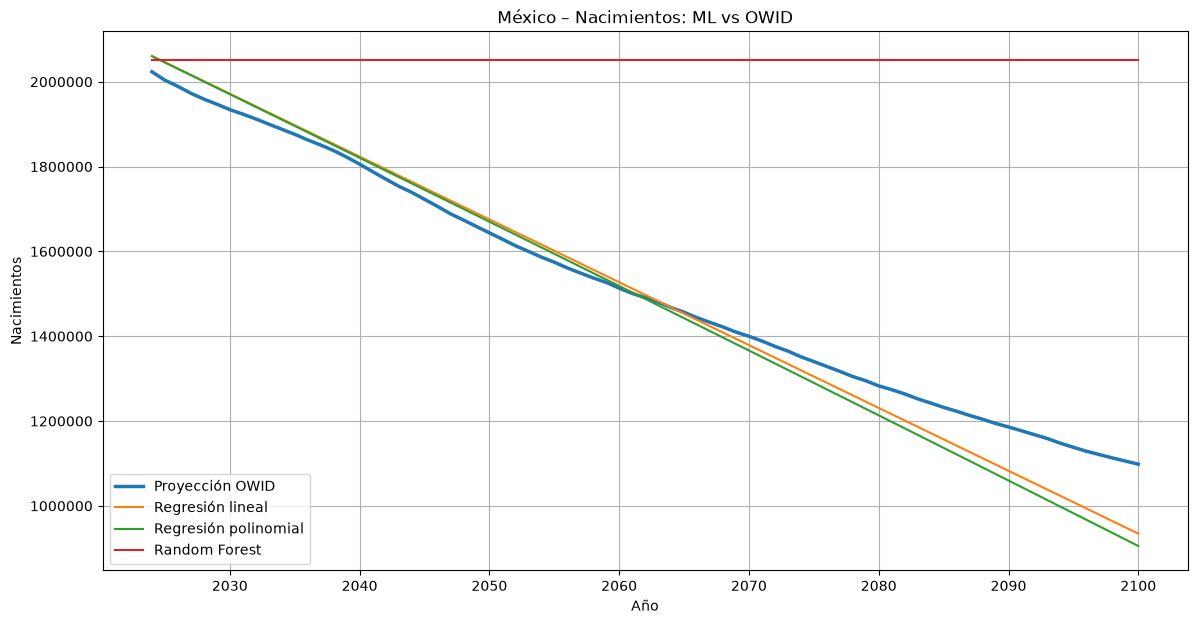

In [23]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_mexico_2000_proyectado["Year"],
    df_mexico_2000_proyectado["births"],
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(X_mexico_futuro["Year"], pred_lineal_mexico_births_fut,
         label="Regresión lineal")

plt.plot(X_mexico_futuro["Year"], pred_poly_mexico_births_fut,
         label="Regresión polinomial")

plt.plot(X_mexico_futuro["Year"], pred_rf_mexico_births_fut,
         label="Random Forest")

plt.title("México – Nacimientos: ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Nacimientos")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

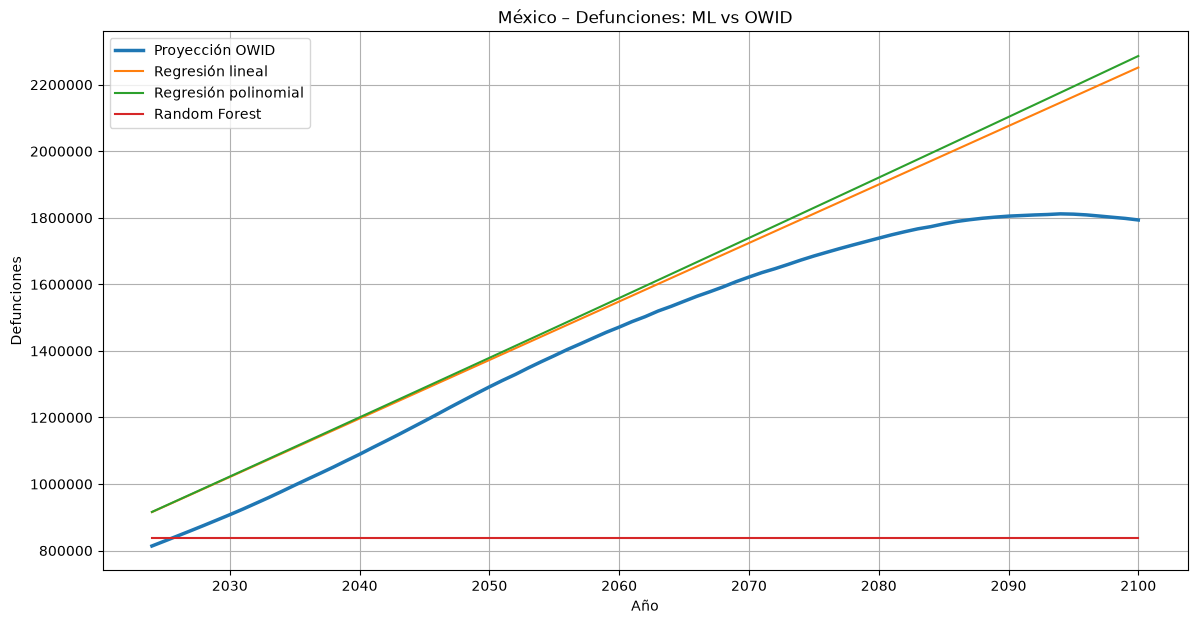

In [24]:
plt.figure(figsize=(14, 7))

plt.plot(
    df_mexico_2000_proyectado["Year"],
    df_mexico_2000_proyectado["deaths"],
    linewidth=2.5,
    label="Proyección OWID"
)

plt.plot(X_mexico_futuro["Year"], pred_lineal_mexico_deaths_fut,
         label="Regresión lineal")

plt.plot(X_mexico_futuro["Year"], pred_poly_mexico_deaths_fut,
         label="Regresión polinomial")

plt.plot(X_mexico_futuro["Year"], pred_rf_mexico_deaths_fut,
         label="Random Forest")

plt.title("México – Defunciones: ML vs OWID")
plt.xlabel("Año")
plt.ylabel("Defunciones")
plt.ticklabel_format(style="plain", axis="y", useOffset=False)
plt.legend()
plt.grid()
plt.show()

# 2.5 Tabla resumen

La tabla permite consultar las predicciones de los tres modelos en algunos años.

In [25]:
anios_tabla = [2030, 2050, 2075, 2100]

def tabla_modelos(anios, lineal, polinomial, rf):
    indices = [np.where(X_mexico_futuro["Year"].to_numpy() == anio)[0][0]
               for anio in anios]

    return pd.DataFrame({
        "Año": anios,
        "Regresión lineal": lineal[indices],
        "Regresión polinomial": polinomial[indices],
        "Random Forest": rf[indices]
    }).set_index("Año")

print("MÉXICO – NACIMIENTOS")
display(
    tabla_modelos(
        anios_tabla,
        pred_lineal_mexico_births_fut,
        pred_poly_mexico_births_fut,
        pred_rf_mexico_births_fut
    ).style.format("{:,.0f}")
)

print("MÉXICO – DEFUNCIONES")
display(
    tabla_modelos(
        anios_tabla,
        pred_lineal_mexico_deaths_fut,
        pred_poly_mexico_deaths_fut,
        pred_rf_mexico_deaths_fut
    ).style.format("{:,.0f}")
)

MÉXICO – NACIMIENTOS


,Regresión lineal,Regresión polinomial,Random Forest
Año,,,
2030,"1,971,876","1,970,689","2,051,955"
2050,"1,675,481","1,669,982","2,051,955"
2075,"1,304,988","1,289,953","2,051,955"
2100,"934,494","905,317","2,051,955"


MÉXICO – DEFUNCIONES


,Regresión lineal,Regresión polinomial,Random Forest
Año,,,
2030,"1,021,129","1,022,528","838,793"
2050,"1,372,705","1,379,209","838,793"
2075,"1,812,175","1,829,978","838,793"
2100,"2,251,646","2,286,211","838,793"


# CONCLUSIONES / OBSERVACIONES

## Ejercicio 1 – China

**Observación:**  
Escribe aquí qué comportamiento observaste en las gráficas de nacimientos y en las predicciones de RL, RP y RF.

## Ejercicio 2 – México desde 2000

**Nacimientos:**  
Escribe aquí qué tendencia observaste y cómo cambia según el modelo.

**Defunciones:**  
Escribe aquí qué tendencia observaste y cómo cambia según el modelo.

### Diferencias entre los modelos

- **Regresión Lineal (RL):** representa la relación mediante una línea recta.
- **Regresión Polinomial (RP):** permite representar una relación curva.
- **Random Forest (RF):** combina múltiples árboles de decisión y puede producir un comportamiento diferente al extrapolar fuera del rango de entrenamiento.
